In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from plasmapy.dispersion import plasma_dispersion_func as zee
from plasmapy.dispersion import plasma_dispersion_func_deriv as zprime
import pandas as pd

# A numerical solver for a multispecies ion plasma dispersion relation
$$1 - \frac{\omega_{p}^2}{2 \left( k v_{the} \right) ^2} Z^\prime \left( \frac{\omega}{\sqrt{ 2 } k v_{the}} \right) - \frac{\Omega_{1}^2}{2 \left( k v_{th_{1}} \right) ^2} Z^\prime \left( \frac{\omega}{\sqrt{ 2 } k v_{th1}} \right) - \frac{\Omega_{2}^2}{2 \left( k v_{th 2} \right) ^2} Z^\prime \left( \frac{\omega}{\sqrt{ 2 } k v_{th 2}} \right) = 0$$

## The method
So it turns out the Newton-Raphson method can be extended to the complex plane with relative ease:
$$z_{n+1} = z_n - \frac{f(z_n)}{f^\prime(z_n)}$$

The direction you approach a root of the function $f(z)$ with a guess does not matter, assuming a well-defined derivative of $f(z)$ exists on the relevant domain.

I pre-compute the derivative of the dielectric terms analytically by using the relation
$$\frac{d}{d\zeta} \left[ z^\prime(\zeta) + 2 \zeta z(\zeta) \right] = z^{\prime\prime} (\zeta) + 2\zeta z^\prime (\zeta) + 2 z(\zeta) = 0$$
which results in an expression for $z^{\prime\prime} (\zeta)$,
$$z^{\prime\prime} (\zeta) = - 2 \left(z (\zeta) + \zeta z^\prime(\zeta)\right)$$

## Notation for normalization
- Some more notation to simplify numerics:
    - $\delta_s = \frac{m_e}{m_s}$
    - $\varepsilon_s = \frac{n_{s0}}{n_{e0}}$
    - $\theta_s = \frac{T_s}{T_e}$
    - $\frac{\Omega_s^2}{\omega_{pe}^2} = \delta_s \varepsilon_s$
    - $\frac{v_s^2}{v_{the}^2} = \delta_s \theta_s$

Resulting in
$$1 - \frac{1}{2 \bar{k}^2} Z^\prime \left( \frac{\bar{\omega}}{\sqrt{2} \bar{k}} \right) - \frac{\varepsilon_1}{2 \theta_1 \bar{k}^2} Z^\prime \left(\frac{\bar{\omega}}{\sqrt{2 \theta_1 \delta_1} \bar{k}} \right) - \frac{\varepsilon_2}{2 \theta_2 \bar{k}^2} Z^\prime \left(\frac{\bar{\omega}}{\sqrt{2 \theta_2 \delta_2} \bar{k}} \right) = 0$$

In [46]:
# kbkb = np.linspace(0.1, 1.5, 1000)
kbkb = np.linspace(0.01, 5, 1000)
wbwb = np.zeros_like(kbkb)

d1 = 1/1000 # me/m1
d2 = 1/100 # me/m2
e1 = 0.9 # n1/ne
e2 = 0.1  # n2/ne
th1 = 0.01 # T1/Te
th2 = 0.01 # T2/Te

In [47]:
Wr_1ion_ub = np.zeros(len(kbkb))
Wi_1ion_ub = np.zeros(len(kbkb))
wr_ub_guess = 1.
wi_ub_guess = 0.

Wr_1ion_lb = np.zeros(len(kbkb))
Wi_1ion_lb = np.zeros(len(kbkb))
wr_lb_guess = 0.
wi_lb_guess = 0.

# for i in range(len(kbkb)):
#     Wr_1ion_ub[i], Wi_1ion_ub[i], D_abs_hist = root_finder_scipy(helper_1ion, kbkb[i], wr_ub_guess, wi_ub_guess)
#     Wr_1ion_lb[i], Wi_1ion_lb[i], D_abs_hist = root_finder_scipy(helper_1ion, kbkb[i], wr_lb_guess, wi_lb_guess)
#     wr_ub_guess = Wr_1ion_ub[i]
#     wr_ub_guess = Wi_1ion_ub[i]
    
#     wr_lb_guess = Wr_1ion_lb[i]
#     wr_lb_guess = Wi_1ion_lb[i]

In [48]:
def D2_z(x):
    return -2*(zee(x) + x*zprime(x))

def two_ion_dielectric_deriv(wb, kb, d1, d2, e1, e2, th1, th2, sq2=np.sqrt(2)):
    # wb = wb_r + 1j*wb_i
    e_term = D2_z(wb/(sq2*kb))
    ion1_term = e1/(th1**3*d1)**0.5*D2_z(wb/(sq2*kb*np.sqrt(th1*d1)))
    ion2_term = e2/(th2**3*d2)**0.5*D2_z(wb/(sq2*kb*np.sqrt(th2*d2)))
    return -1/(sq2*kb)**3 * (e_term + ion1_term + ion2_term)

def two_ion_dielectric(wb, kb, d1, d2, e1, e2, th1, th2):
    # wb = wb_r + 1j * wb_i
    electron_term = 1/(2*kb*kb) * zprime(wb/(np.sqrt(2)*kb))
    ion1_term = e1/(2*th1) / (kb*kb) * zprime(np.sqrt(1/(2*d1*th1)) * wb/kb)
    ion2_term = e2/(2*th2) / (kb*kb) * zprime(np.sqrt(1/(2*d2*th2)) * wb/kb)
    return 1 - electron_term - ion1_term - ion2_term
 
def complex_newton_step(f, fprime, z_guess):
    return z_guess - f(z_guess) / fprime(z_guess)

def complex_newton_solve(f, fprime, z0 : np.complex128, max_iter=1000, tol=1e-12):
    z_guess = z0
    for i in range(max_iter):
        if np.abs(f(z_guess)) < tol:
            return z_guess, i
            
        z_guess = complex_newton_step(f, fprime, z_guess)

    return np.nan, i
        

w_2ion_ub = np.zeros(len(kbkb), dtype=np.complex128)
n_iter_ub = np.zeros(len(kbkb), dtype=np.int16)
w_ub_guess = 1. + 0j
for i in range(len(kbkb)):
    def helper_2ion(w):
        return two_ion_dielectric(w, kbkb[i], d1, d2, e1, e2, th1, th2)

    def helper_2ion_deriv(w):
        return two_ion_dielectric_deriv(w, kbkb[i], d1, d2, e1, e2, th1, th2)

    def solver(z_guess):
        return complex_newton_solve(helper_2ion, helper_2ion_deriv, z_guess)
        
    w_2ion_ub[i], n_iter_ub[i] = solver(w_ub_guess)

    w_ub_guess = w_2ion_ub[i]
    
w_2ion_lb1 = np.zeros(len(kbkb), dtype=np.complex128)
w_2ion_lb2 = np.zeros(len(kbkb), dtype=np.complex128)

n_iter_lb1 = np.zeros(len(kbkb), dtype=np.int16)
n_iter_lb2 = np.zeros(len(kbkb), dtype=np.int16)
w_lb1_guess = np.sqrt(d1) - 0.01j
w_lb2_guess = np.sqrt(d2) - 0.001j

# I traverse the klD space backwards from the maximum value because
# I just knew that the IAW branch asymptotically approaches the ion oscillation frequency
for i in range(len(kbkb)-1, 0, -1):
    def helper_2ion(w):
        return two_ion_dielectric(w, kbkb[i], d1, d2, e1, e2, th1, th2)

    def helper_2ion_deriv(w):
        return two_ion_dielectric_deriv(w, kbkb[i], d1, d2, e1, e2, th1, th2)

    def solver(z_guess):
        return complex_newton_solve(helper_2ion, helper_2ion_deriv, z_guess)
        
    w_2ion_lb1[i], n_iter_lb1[i] = solver(w_lb1_guess)
    w_2ion_lb2[i], n_iter_lb2[i] = solver(w_lb2_guess)
    
    w_lb1_guess = w_2ion_lb1[i]
    w_lb2_guess = w_2ion_lb2[i]

/home/mattketk/Workspaces/Projects/brillouin-multispecies/.venv/lib/python3.13/site-packages/plasmapy/dispersion/dispersion_functions.py:67: RuntimeWarning: invalid value encountered in scalar multiply
  return 1j * np.sqrt(np.pi) * faddeeva_function(zeta)
/tmp/ipykernel_386860/3129844809.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return z_guess - f(z_guess) / fprime(z_guess)


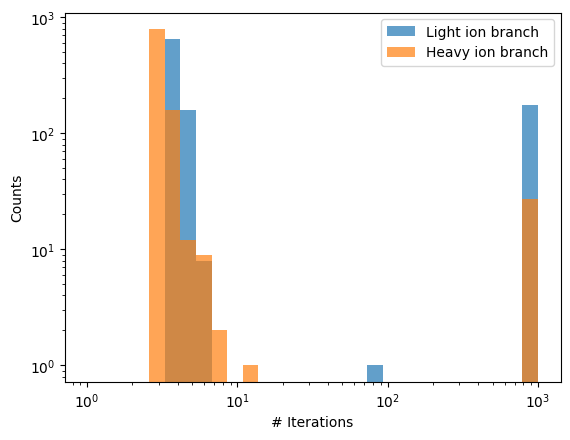

In [49]:
plt.hist(n_iter_lb2, bins=np.logspace(0, 3, 30), alpha=0.7, label='Light ion branch')
plt.hist(n_iter_lb1, bins=np.logspace(0, 3, 30), alpha=0.7, label='Heavy ion branch')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('# Iterations')
plt.ylabel('Counts')
plt.legend()

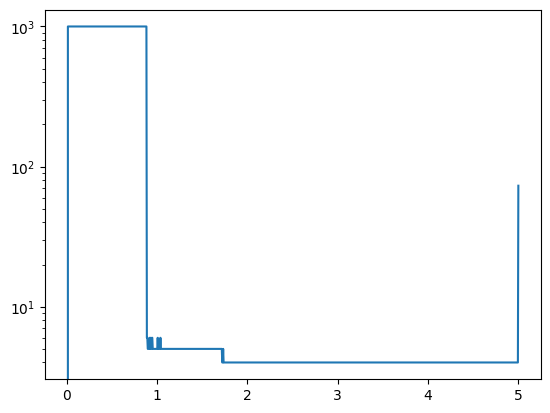

In [61]:
plt.semilogy(kbkb, n_iter_lb2)

In [50]:
kbkb[::len(kbkb)//10]

array([0.01     , 0.5094995, 1.008999 , 1.5084985, 2.007998 , 2.5074975,
       3.006997 , 3.5064965, 4.005996 , 4.5054955])

In [51]:
np.real(w_2ion_lb1[::len(w_2ion_lb1)//10])

array([0.        , 0.00535785, 0.01062954, 0.01591939, 0.021163  ,
       0.02614732, 0.0305286 , 0.03416642, 0.037234  , 0.03994535])

In [52]:
sim_data_n1 = pd.read_csv('TeTi-10_n1_damping-rates.csv')
klD_n1 = sim_data_n1['kλD']
wi_n1 = sim_data_n1['wi (sim)']
wi_stdev_n1 = sim_data_n1['wi stdev (sim)']
sim_data_n1

,kλD,wi (sim),wi stdev (sim)
0,0.240140,-0.000828,0.000053
1,0.380280,-0.001840,0.000038
2,0.520420,-0.002460,0.000061
3,0.660561,-0.002770,0.000118
4,0.800701,-0.003490,0.000132
5,0.940841,-0.007280,0.000236
6,1.080981,-0.007450,0.000493
7,1.221121,-0.010900,0.000780
8,1.361261,-0.009600,0.000732


In [53]:
sim_data = pd.read_csv('TeTi-10-sims_damping-rates.csv')
klD = sim_data['kλD']
wi = sim_data['wi (sim)']
wi_stdev = sim_data['wi stdev (sim)']
sim_data

,kλD,wi (sim),wi stdev (sim)
0,0.240140,-0.000766,0.000170
1,0.380280,-0.002020,0.000184
2,0.520420,-0.002790,0.000418
3,0.660561,-0.002550,0.000360
4,0.800701,-0.004170,0.000505
5,0.940841,-0.006370,0.000771
6,1.080981,-0.007410,0.000877
7,1.221121,-0.012500,0.001150
8,1.361261,-0.008390,0.002020


In [54]:
np.isnan(w_2ion_lb2).sum() / len(w_2ion_lb2)

np.float64(0.175)

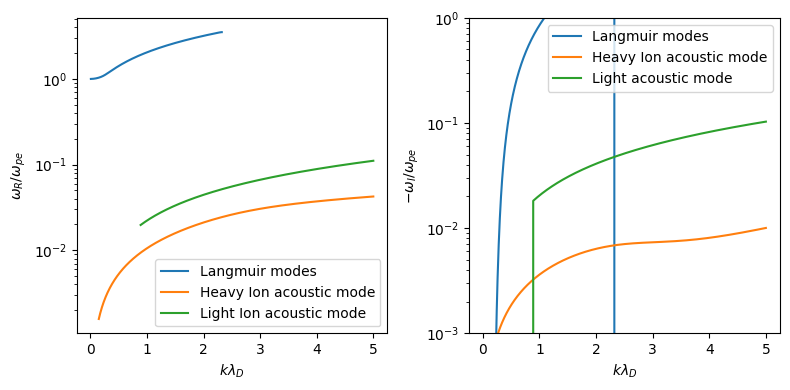

In [62]:
fig, (ax_r, ax_i) = plt.subplots(1, 2, figsize=(8,4))
ax_r.plot(kbkb, np.real(w_2ion_ub), label='Langmuir modes')
ax_r.plot(kbkb, np.real(w_2ion_lb1), label='Heavy Ion acoustic mode')
ax_r.plot(kbkb, np.real(w_2ion_lb2), label='Light Ion acoustic mode')
ax_r.set_xlabel(r'$k\lambda_D$')
ax_r.set_ylabel(r'$\omega_R / \omega_{pe}$')
ax_r.set_yscale('log')
# ax_r.axhline(np.sqrt(d1))
# ax_r.set_xlim([0.2, 0.25])
# ax_r.set_ylim([1.4e-2, 1.6e-2])
ax_r.legend()
# plt.savefig('/home/mattketk/rotw/figures/two_ion_dispersion_real.png', dpi=200)

ax_i.plot(kbkb, -np.imag(w_2ion_ub), label='Langmuir modes')
ax_i.plot(kbkb, -np.imag(w_2ion_lb1), label='Heavy Ion acoustic mode')
ax_i.plot(kbkb, -np.imag(w_2ion_lb2), label='Light acoustic mode')
# ax_i.errorbar(klD, -wi, yerr=wi_stdev, fmt='o', ms=4, label='Simulation results e1')
# ax_i.errorbar(klD_n1, -wi_n1, yerr=wi_stdev_n1, fmt='o', ms=4, label='Simulation results n1')
ax_i.set_xlabel(r'$k\lambda_D$')
ax_i.set_ylabel(r'$-\omega_I / \omega_{pe}$')
ax_i.set_yscale('log')
# ax_i.set_xlim([0.11, 1.])
ax_i.set_ylim([1e-3, 1.])
# ax_i.set_ylim([1e-5, 8e-2])
ax_i.legend()

fig.tight_layout()
# fig.savefig('/home/mattketk/rotw/figures/theory-sim_damping-agreement.png', dpi=200)

# np.save('/home/mattketk/rotw/data/kbkb.npy', kbkb)
# np.save('/home/mattketk/rotw/data/w_2ion_ub.npy', w_2ion_ub)
# np.save('/home/mattketk/rotw/data/w_2ion_lb1.npy', w_2ion_lb1)

## Shotgunning a bunch of guesses near a known root to explore other branches of the dispersion relation

In [17]:
k

np.float64(0.24514514514514515)

In [6]:
real_width = 5e-3
imag_width = 5e-2
n_random = 10000
root = w_2ion_lb1[50]
k = kbkb[50]

rand_real = 2*real_width * np.random.random(size=n_random) + (np.real(root) - real_width)
rand_imag = 2*imag_width * np.random.random(size=n_random) + (np.imag(root) - imag_width)
guesses = rand_real + 1j * rand_imag



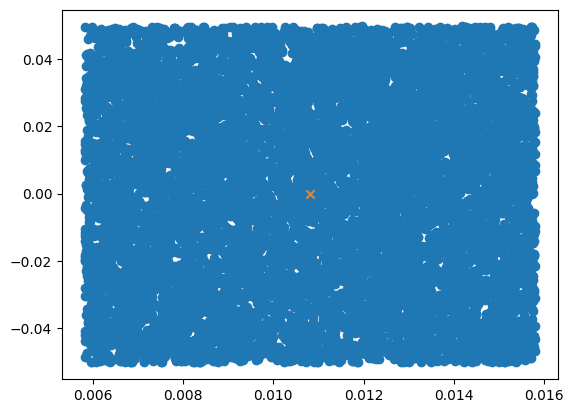

In [7]:
plt.scatter(np.real(guesses), np.imag(guesses))
plt.scatter(np.real(root), np.imag(root), marker='x')

In [8]:
root_candidates = np.zeros_like(guesses, dtype=np.complex128)
for i in range(len(guesses)):
    def helper_2ion(w):
        return two_ion_dielectric(w, k, d1, d2, e1, e2, th1, th2)

    def helper_2ion_deriv(w):
        return two_ion_dielectric_deriv(w, k, d1, d2, e1, e2, th1, th2)

    def solver(z_guess):
        return complex_newton_solve(helper_2ion, helper_2ion_deriv, z_guess)

    root_candidates[i] = solver(guesses[i])

6
105
393
6
16
589
5
352
72
8
66
236
7
248
5
6
7


/home/mattketk/Workspaces/Projects/brillouin-multispecies/.venv/lib/python3.13/site-packages/plasmapy/dispersion/dispersion_functions.py:67: RuntimeWarning: invalid value encountered in scalar multiply
  return 1j * np.sqrt(np.pi) * faddeeva_function(zeta)
/tmp/ipykernel_386860/3597074282.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return z_guess - f(z_guess) / fprime(z_guess)


651
7
8
5
118
6
7
112
151
100
151
583
7
23
989


/tmp/ipykernel_386860/3597074282.py:7: RuntimeWarning: overflow encountered in scalar multiply
  ion1_term = e1/(th1**3*d1)**0.5*D2_z(wb/(sq2*kb*np.sqrt(th1*d1)))
/tmp/ipykernel_386860/3597074282.py:9: RuntimeWarning: invalid value encountered in scalar multiply
  return -1/(sq2*kb)**3 * (e_term + ion1_term + ion2_term)


222
414
6
197
463
7
7
56
5
117
324
5
443
5
468
654
603
12
234
45
168
6
5
11
241
7
244
431
636
677
8
75
67
499
290
79
6
13
7
12
6
7
123
8
68
6
152
12
59
335
6
306
510
102


...

265
25
482
6
7
148
5
11
408
53
620
7
450
9
37
5
8
15
135
37
5
118
282
7
7
100
603
4
12
8
358
454
107
43
499
8
528
9
7
9
284
112
606
699
264
7
422
8
6
598
18
176
136
85
5
159
214
626
7
12
130
160
11
123
282
348
635
542
349
295
19
148
526
7
28
81
188
385
61
191
21
113
353
6
8
6
546
57
29
121
149
141
209
98
6
364
8
510
278
5
9
6
428
487
15
196
691
8
499
6
680
583
186
10
168
201
328
49
40
339
6
60
184
528
324
51
29
46
668
359
348
5
6
698
129
5
546
140
88
236
107
95
7
45
485
43
6
295
299
105
38
8
369
409
7
19
5
6
124
122
7
31
392
9
7
8
27
6
7
317
7
8
9
614
5
226
6
680
528
68
481
420
53
7
5
7
474
143
5
408
62
118
6
6
25
253
7


/tmp/ipykernel_386860/3597074282.py:14: RuntimeWarning: invalid value encountered in scalar multiply
  ion1_term = e1/(2*th1) / (kb*kb) * zprime(np.sqrt(1/(2*d1*th1)) * wb/kb)
/tmp/ipykernel_386860/3597074282.py:15: RuntimeWarning: invalid value encountered in scalar multiply
  ion2_term = e2/(2*th2) / (kb*kb) * zprime(np.sqrt(1/(2*d2*th2)) * wb/kb)


7
138
43
49
6
7
464
175
25
363
6
621
113
25
245
419
347
15
239
8
138
6
411
7
5
326
434
88
7
9
5
6
215
180
94
6
6
133
194
200
55
585
6
253
8
583
7
198
90
213
447
26
166
8
14
4
132
354
301
6
9
697
92
7
6
5
7
196
288
10
8
134
7
346
28
271
5
71
43
8
33
204
333
47
6
182
6
466
365
560
546
243
371
320
459
228
331
21
138
278
23
53
65
89
79
6
65
8
5
227
107
340
92
444
171
161
154
126
7
168
7
6
7
8
8
273
361
237
157
378
12
103
76
254
74
34
7
209
24
5
6
9
322
6
334
7
6
351
231
13
11
47
6
128
7
39
88
364
526
6
295
60
43
82
9
7
6
5
8
20
6
5
112
468
33
5
7
141
398
471
173
190
6
5
547
4
5
5
525
152
11
119
7
10
219
423
42
45
7
420
325
5
9
8
292
8
706
241
205
89
658
9
323
15
668
392
380
507
49
13
90
48
46
165
83
165
16
66
133
7
340
261
565
38
26
234
430
342
6
7
6
6
88
8
140
119
129
6
611
6
180
597
153
7
6
416
127
12
13
31
206
6
594
559
602
218
450
269
267
207
33
11
157
531
98
8
510
14
191
325
32
5
199
7
9
8
179
367
124
7
120
18
307
8
8
7
7
184
180
136
43
6
6
190
149
6
246
627
136
60
7
565
163
227
10
63

/tmp/ipykernel_386860/3597074282.py:7: RuntimeWarning: invalid value encountered in scalar multiply
  ion1_term = e1/(th1**3*d1)**0.5*D2_z(wb/(sq2*kb*np.sqrt(th1*d1)))
/tmp/ipykernel_386860/3597074282.py:8: RuntimeWarning: invalid value encountered in scalar multiply
  ion2_term = e2/(th2**3*d2)**0.5*D2_z(wb/(sq2*kb*np.sqrt(th2*d2)))


44
573
281
392
352
5
7
7
330
6
259
618
106
127
9
47
183
59
511
148
7
7
35
234
11
45
55
359
20
254
170
479
87
63
230
374
392
56
262
9
14
496
5
152
9
4
7
75
190
500
419
400
103
101
12
547
576
6
72
8
7
459
392
8
173
604
7
44
202
454
6
19
7
7
496
508
6
350
10
7
377
49
38
435
6
42
244
180
323
715
426
41
522
5
198
8
211
7
9
7
319
285
444
20
11
567
141
667
6
6
224
240
530
7
356
261
677
158
85
223
7
21
11
370
7
129
5
257
382
6
7
234
59
116
198
8
8
6
31
101
80
451
610
7
259
5
261
148
12
277
21
392
470
5
306
476
9
113
359
286
8
601
6
12
6
9
660
557
412
13
45
6
277
94
564
380
4
50
646
6
304
17
7
310
44
620
472
6
6
5
208
353
385
171
481
42
290
330
218
529
606
516
6
95
230
246
7
589
9
630
553
62
16
5
8
7
449
25
12
24
393
4
94
286
7
502
686
281
5
56
274
27
6
327
510
22
5
7
47
175
16
107
140
6
55
302
7
252
6
274
379
239
227
430
331
290
546
16
194
373
234
180
30
28
147
6
7
558
6
271
115
51
395
182
382
23
214
303
291
519
4
299
620
654
5
144
384
50
43
140
5
219
204
167
640
507
5
6
6
6
369
56
24
283
38
2

In [9]:
filtered_root_candidates = []
for i in range(len(root_candidates)):
    if not np.isnan(root_candidates[i]):
        filtered_root_candidates.append(root_candidates[i])

filtered_root_candidates = np.array(filtered_root_candidates)
print(len(filtered_root_candidates) / len(root_candidates))

0.3849


0.010811542884164303
-0.00027295404935464174


Text(0, 0.5, '$-\\omega_I/\\omega_{pe}$')

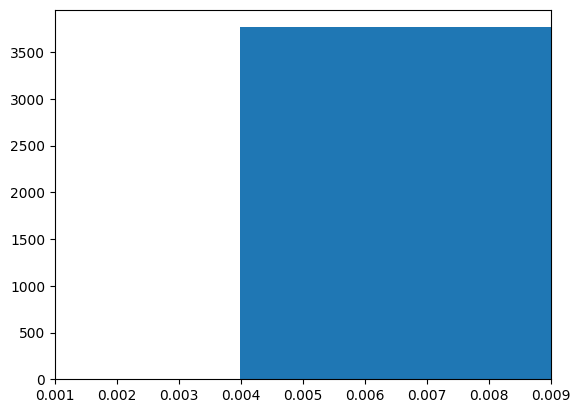

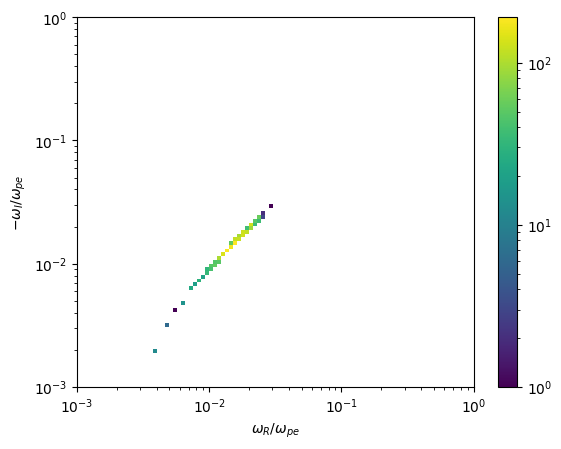

In [12]:
plt.figure()
counts, bins, _ = plt.hist(np.abs(np.real(root_candidates)))
plt.axvline(np.real(root), ls='--', c='k')
# plt.xscale('log')
plt.xlim([1e-3, 9e-3])
# plt.yscale('log')

plt.figure()
# plt.hist2d(np.nan_to_num(np.real(root_candidates)), np.nan_to_num(np.imag(root_candidates)))
hist2d_norm_log = mpl.colors.LogNorm()
plt.hist2d(
    np.real(filtered_root_candidates),
    -np.imag(filtered_root_candidates),
    bins=[np.logspace(-3, 0, 100), np.logspace(-3, 0, 100)],
    norm=hist2d_norm_log
)
# plt.scatter(np.real(root), -np.imag(root), marker='*', markersize=4)
print(np.real(root))
print(np.imag(root))
plt.colorbar()
plt.xscale('log')
plt.yscale('log')


plt.xlabel(r'$\omega_R/\omega_{pe}$')
plt.ylabel(r'$-\omega_I/\omega_{pe}$')